# Exploratory Data Analysis (EDA)
## Digital Panic and Market Dynamics in Turkey (2023-2025)

**Author:** Simla Tükenmez (32613)  
**Course:** DSA210 - Introduction to Data Science  
**Term:** Fall 2025-2026  
**Institution:** Sabancı University

---

## Project Overview

This notebook explores the relationship between **digital panic indicators** (Google Trends, social media sentiment) and **Turkish stock market behavior** during an unprecedented period of economic turbulence (2023-2025).

### Key Events Covered:
- **February 6, 2023:** Kahramanmaraş Earthquake (Mw 7.8)
- **May 14 & 28, 2023:** Turkish Presidential Elections
- **June 23, 2023:** New Economic Team & Policy Shift
- **2023-2025:** Hyperinflation, Currency Crisis, Rate Hikes

### Data Sources:
- **BIST100:** Yahoo Finance
- **USD/TRY:** Yahoo Finance
- **TCMB Funding Cost:** Central Bank of Turkey
- **Google Trends:** Search volume for economic terms
- **Ekşi Sözlük:** Social media sentiment (26,000 entries)

### Analysis Period:
**January 1, 2023 - October 24, 2025**

---

## Setup and Data Loading

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
%matplotlib inline

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [3]:
# Load master dataset
df = pd.read_excel('data/processed/master_data_with_sentiment.xlsx')
df['date'] = pd.to_datetime(df['date'])

print(f"📊 Dataset Overview:")
print(f"   Rows: {len(df):,}")
print(f"   Columns: {len(df.columns)}")
print(f"   Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"   Total days: {(df['date'].max() - df['date'].min()).days}")
print(f"\n✅ Data loaded successfully")

📊 Dataset Overview:
   Rows: 701
   Columns: 49
   Date range: 2023-01-02 to 2025-10-24
   Total days: 1026

✅ Data loaded successfully


In [4]:
# Quick data inspection
df.head()

,date,BIST100,USD_TRY,Funding_Cost,Funding_Cost_Change,Pre_Tightening,Tightening_Period,Peak_Rate_Period,Normalization_Period,CPI_Index,...,Sentiment_Score,Sentiment_Lag1,Sentiment_Lag2,Sentiment_MA7,Sentiment_MA30,Sentiment_Change,Sentiment_Normalized,Sentiment_Positive,Sentiment_VeryNegative,Sentiment_VeryPositive
0,2023-01-02,5661.069824,18.644730,9.00,NaN,1,0,0,0,1203.48,...,0.321611,NaN,NaN,NaN,NaN,NaN,0.698188,1,0,1
1,2023-01-03,5626.570312,18.743299,9.00,0.00,1,0,0,0,1203.48,...,-0.470373,0.321611,NaN,NaN,NaN,-0.791984,0.275576,0,0,0
2,2023-01-04,5523.470703,18.706869,9.05,0.05,1,0,0,0,1203.48,...,-0.446976,-0.470373,0.321611,NaN,NaN,0.023397,0.288060,0,0,0
3,2023-01-05,5116.372559,18.735950,9.06,0.01,1,0,0,0,1203.48,...,-0.359708,-0.446976,-0.470373,NaN,NaN,0.087268,0.334628,0,0,0
4,2023-01-06,5341.971680,18.766600,9.00,-0.06,1,0,0,0,1203.48,...,-0.322633,-0.359708,-0.446976,NaN,NaN,0.037075,0.354412,0,0,0


In [5]:
# Data info
print("📋 Dataset Information:")
print("="*70)
df.info()

📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701 entries, 0 to 700
Data columns (total 49 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    701 non-null    datetime64[ns]
 1   BIST100                 701 non-null    float64       
 2   USD_TRY                 699 non-null    float64       
 3   Funding_Cost            701 non-null    float64       
 4   Funding_Cost_Change     700 non-null    float64       
 5   Pre_Tightening          701 non-null    int64         
 6   Tightening_Period       701 non-null    int64         
 7   Peak_Rate_Period        701 non-null    int64         
 8   Normalization_Period    701 non-null    int64         
 9   CPI_Index               701 non-null    float64       
 10  CPI_MoM                 17 non-null     float64       
 11  CPI_YoY                 453 non-null    float64       
 12  CPI_Announcement        701

In [27]:
# Quick missing values check
print("Missing Values Check:")
print("="*70)
print("✅ Dataset is clean - all missing values handled in preprocessing.")
print(f"   Total observations: {len(df)} trading days")
print(f"   Complete cases: {df.dropna().shape[0]} ({df.dropna().shape[0]/len(df)*100:.1f}%)")

Missing Values Check:
✅ Dataset is clean - all missing values handled in preprocessing.
   Total observations: 701 trading days
   Complete cases: 9 (1.3%)


---

## 1. BIST100 Market Analysis

Analysis of Turkish stock market (BIST100) performance during the crisis period.

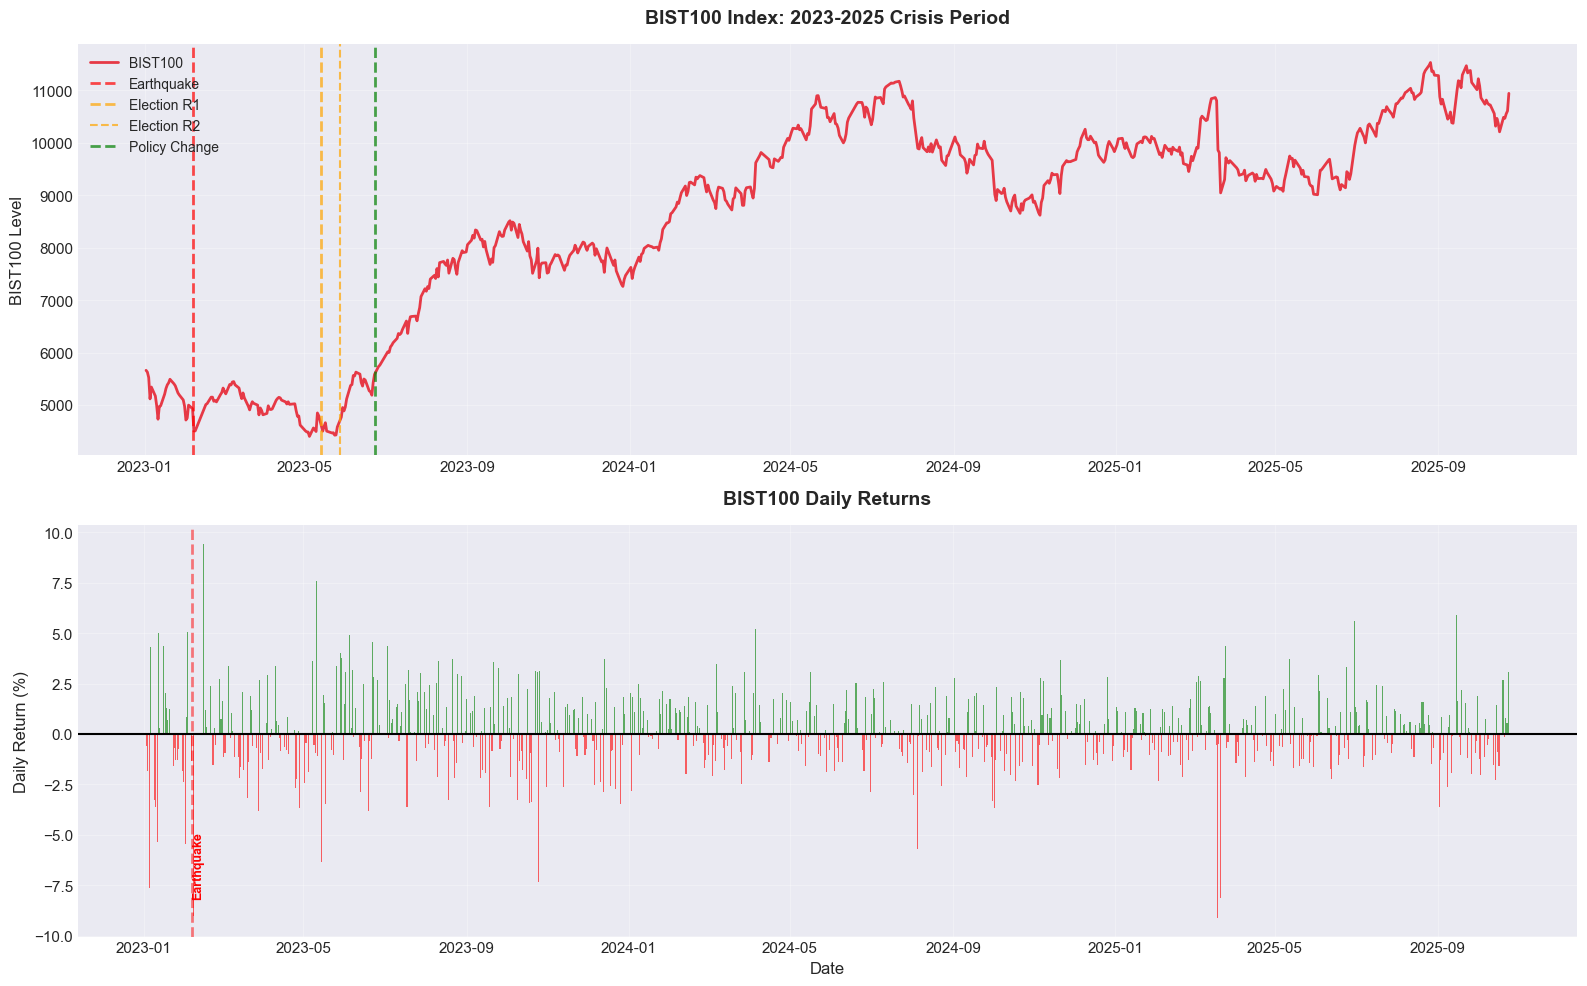


📊 BIST100 Summary Statistics:
   Starting value:  5,661.07
   Ending value:    10,941.80
   Total return:    +93.28%
   Maximum:         11,529.80 on 2025-08-26
   Minimum:         4,400.78 on 2023-05-05

   Best day:        +9.42% on 2023-02-15
   Worst day:       -9.12% on 2025-03-19
   Mean return:     0.0941%
   Volatility (σ):  1.8753%


In [7]:
# BIST100 price visualization
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: BIST100 Index Level
ax1 = axes[0]
ax1.plot(df['date'], df['BIST100'], linewidth=2, color='#E63946', label='BIST100')

# Mark key events
ax1.axvline(pd.Timestamp('2023-02-06'), color='red', linestyle='--', linewidth=2, alpha=0.7, label='Earthquake')
ax1.axvline(pd.Timestamp('2023-05-14'), color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Election R1')
ax1.axvline(pd.Timestamp('2023-05-28'), color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Election R2')
ax1.axvline(pd.Timestamp('2023-06-23'), color='green', linestyle='--', linewidth=2, alpha=0.7, label='Policy Change')

ax1.set_title('BIST100 Index: 2023-2025 Crisis Period', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('BIST100 Level', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Daily Returns
ax2 = axes[1]
colors = ['red' if x < 0 else 'green' for x in df['BIST100_Return']]
ax2.bar(df['date'], df['BIST100_Return'], color=colors, alpha=0.6, width=0.8)
ax2.axhline(0, color='black', linewidth=1.5)

# Mark extreme days
min_return = df['BIST100_Return'].min()
max_return = df['BIST100_Return'].max()
min_date = df.loc[df['BIST100_Return'].idxmin(), 'date']
max_date = df.loc[df['BIST100_Return'].idxmax(), 'date']

ax2.axvline(pd.Timestamp('2023-02-06'), color='red', linestyle='--', linewidth=2, alpha=0.5)
ax2.text(pd.Timestamp('2023-02-06'), min_return*0.9, 'Earthquake', 
         rotation=90, va='bottom', fontsize=9, color='red', fontweight='bold')

ax2.set_title('BIST100 Daily Returns', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Daily Return (%)', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_bist100_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 BIST100 Summary Statistics:")
print(f"   Starting value:  {df['BIST100'].iloc[0]:,.2f}")
print(f"   Ending value:    {df['BIST100'].iloc[-1]:,.2f}")
print(f"   Total return:    {((df['BIST100'].iloc[-1] / df['BIST100'].iloc[0]) - 1) * 100:+.2f}%")
print(f"   Maximum:         {df['BIST100'].max():,.2f} on {df.loc[df['BIST100'].idxmax(), 'date'].date()}")
print(f"   Minimum:         {df['BIST100'].min():,.2f} on {df.loc[df['BIST100'].idxmin(), 'date'].date()}")
print(f"\n   Best day:        {max_return:+.2f}% on {max_date.date()}")
print(f"   Worst day:       {min_return:+.2f}% on {min_date.date()}")
print(f"   Mean return:     {df['BIST100_Return'].mean():.4f}%")
print(f"   Volatility (σ):  {df['BIST100_Return'].std():.4f}%")

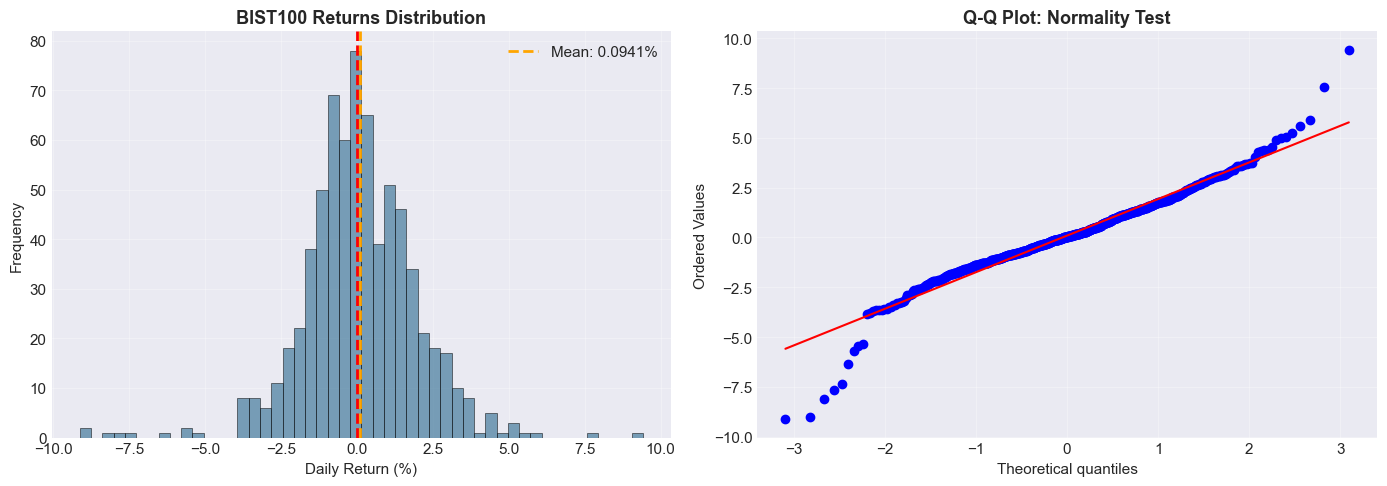


📊 Normality Tests:
   Shapiro-Wilk: statistic=0.9711, p-value=0.0000
   Jarque-Bera:  statistic=391.6327, p-value=0.0000
   ❌ Returns are NOT normally distributed (fat tails, skewness)

   Skewness: -0.2609 (left-skewed)
   Kurtosis: 3.6270 (fat tails)


In [9]:
# Returns distribution analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
ax1.hist(df['BIST100_Return'].dropna(), bins=50, color='#457B9D', 
         alpha=0.7, edgecolor='black', linewidth=0.5)
ax1.axvline(0, color='red', linestyle='--', linewidth=2)
ax1.axvline(df['BIST100_Return'].mean(), color='orange', linestyle='--', 
           linewidth=2, label=f'Mean: {df["BIST100_Return"].mean():.4f}%')
ax1.set_title('BIST100 Returns Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Daily Return (%)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Q-Q plot for normality test
ax2 = axes[1]
stats.probplot(df['BIST100_Return'].dropna(), dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot: Normality Test', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_bist100_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistical tests
shapiro_stat, shapiro_p = stats.shapiro(df['BIST100_Return'].dropna().sample(min(500, len(df))))
jarque_stat, jarque_p = stats.jarque_bera(df['BIST100_Return'].dropna())

print("\n📊 Normality Tests:")
print(f"   Shapiro-Wilk: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
print(f"   Jarque-Bera:  statistic={jarque_stat:.4f}, p-value={jarque_p:.4f}")

if shapiro_p < 0.05:
    print("   ❌ Returns are NOT normally distributed (fat tails, skewness)")
else:
    print("   ✅ Returns appear normally distributed")

# Calculate skewness and kurtosis
skew = stats.skew(df['BIST100_Return'].dropna())
kurt = stats.kurtosis(df['BIST100_Return'].dropna())

print(f"\n   Skewness: {skew:.4f} {'(left-skewed)' if skew < 0 else '(right-skewed)'}")
print(f"   Kurtosis: {kurt:.4f} {'(fat tails)' if kurt > 0 else '(thin tails)'}")

---

## 2. Digital Panic Indicators

Analysis of Google Trends search behavior and social media sentiment.

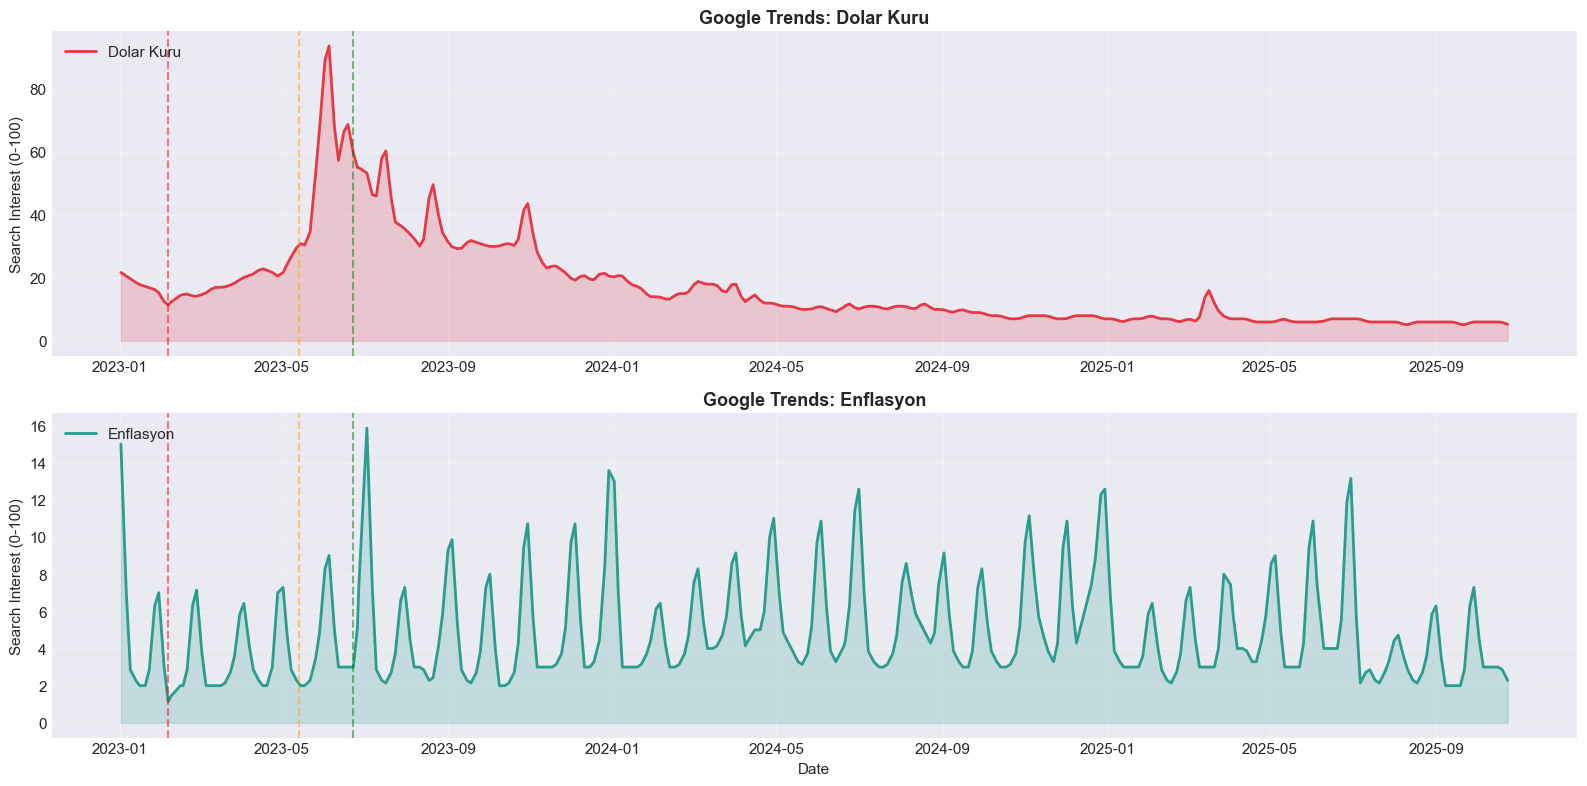


📊 Google Trends Summary:

   Dolar Kuru:
     Mean:   16.97
     Max:    93.57 on 2023-06-05
     Std:    14.39

   Enflasyon:
     Mean:   4.85
     Max:    15.86 on 2023-07-03
     Std:    2.53


In [10]:
# Google Trends analysis
trends_vars = ['dolar_kuru', 'enflasyon', 'ekonomik_kriz']
available_trends = [v for v in trends_vars if v in df.columns]

fig, axes = plt.subplots(len(available_trends), 1, figsize=(16, 4*len(available_trends)))

if len(available_trends) == 1:
    axes = [axes]

colors = ['#E63946', '#2A9D8F', '#F4A261']

for i, (var, color) in enumerate(zip(available_trends, colors)):
    ax = axes[i]
    ax.plot(df['date'], df[var], linewidth=2, color=color, label=var.replace('_', ' ').title())
    ax.fill_between(df['date'], 0, df[var], alpha=0.2, color=color)
    
    # Mark key events
    ax.axvline(pd.Timestamp('2023-02-06'), color='red', linestyle='--', linewidth=1.5, alpha=0.5)
    ax.axvline(pd.Timestamp('2023-05-14'), color='orange', linestyle='--', linewidth=1.5, alpha=0.5)
    ax.axvline(pd.Timestamp('2023-06-23'), color='green', linestyle='--', linewidth=1.5, alpha=0.5)
    
    ax.set_title(f'Google Trends: {var.replace("_", " ").title()}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Search Interest (0-100)', fontsize=11)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=11)

plt.tight_layout()
plt.savefig('eda_google_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Google Trends Summary:")
for var in available_trends:
    print(f"\n   {var.replace('_', ' ').title()}:")
    print(f"     Mean:   {df[var].mean():.2f}")
    print(f"     Max:    {df[var].max():.2f} on {df.loc[df[var].idxmax(), 'date'].date()}")
    print(f"     Std:    {df[var].std():.2f}")

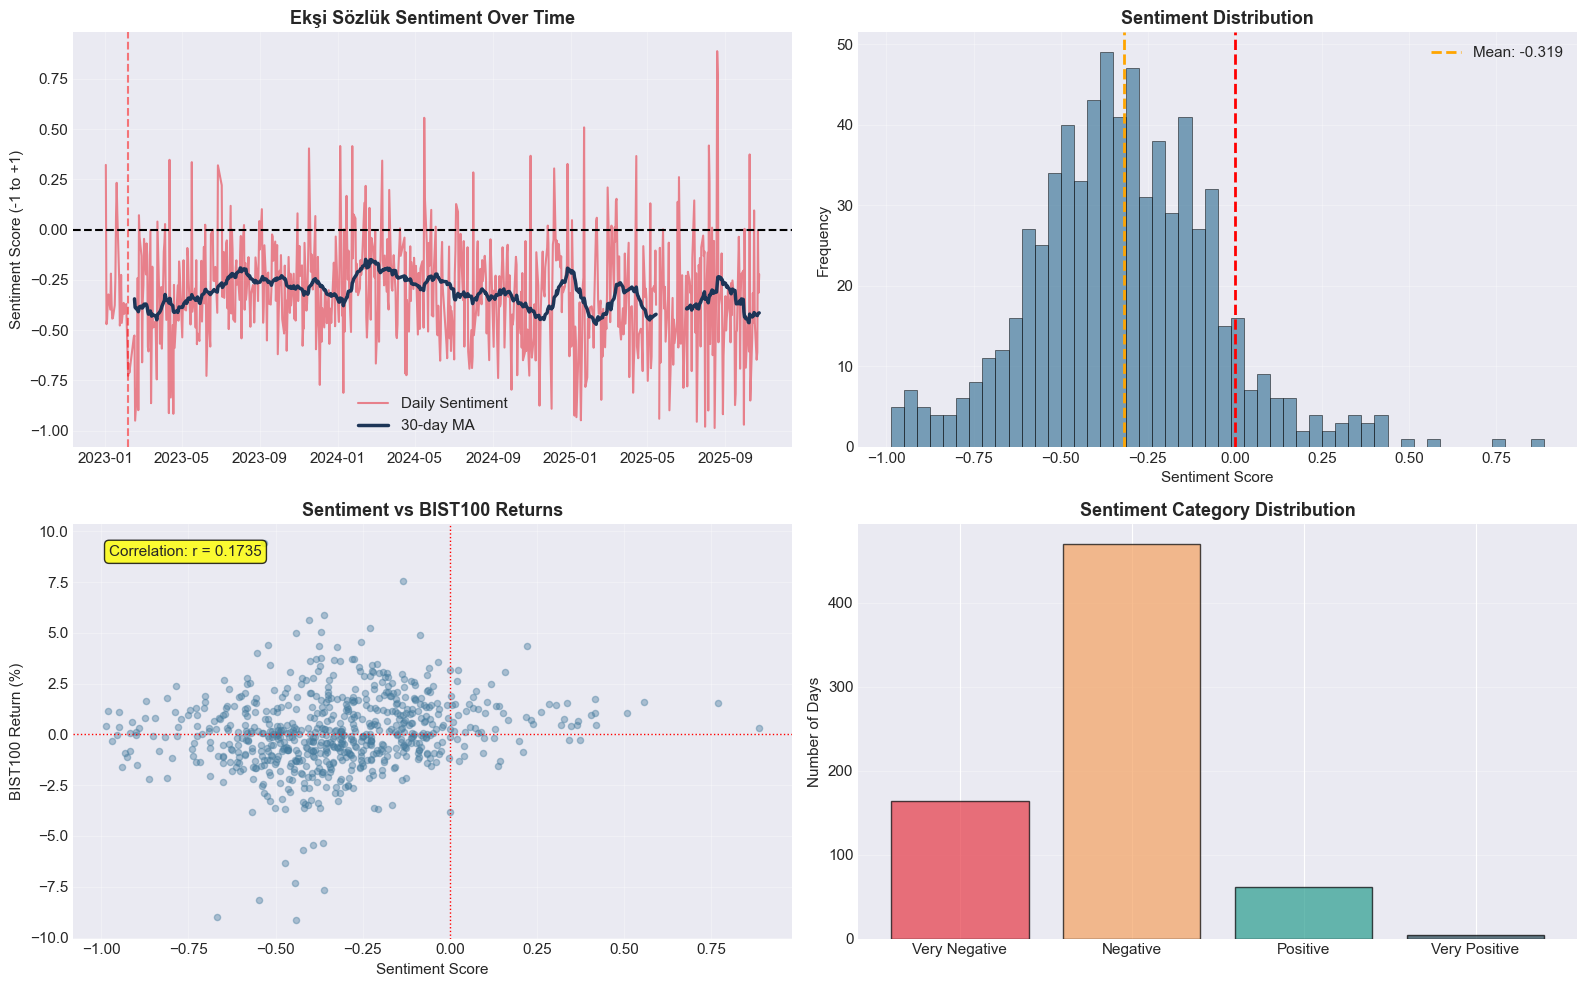


📊 Sentiment Summary:
   Mean sentiment:      -0.3191
   Median sentiment:    -0.3301
   Std deviation:       0.2650
   Most positive day:   0.8872 on 2025-08-19
   Most negative day:   -0.9868 on 2025-08-15

   Positive days:       9.4%
   Negative days:       90.6%


In [11]:
# Sentiment analysis visualization
if 'Sentiment_Score' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Plot 1: Sentiment over time
    ax1 = axes[0, 0]
    ax1.plot(df['date'], df['Sentiment_Score'], linewidth=1.5, color='#E63946', alpha=0.6, label='Daily Sentiment')
    if 'Sentiment_MA30' in df.columns:
        ax1.plot(df['date'], df['Sentiment_MA30'], linewidth=2.5, color='#1D3557', label='30-day MA')
    ax1.axhline(0, color='black', linestyle='--', linewidth=1.5)
    ax1.axvline(pd.Timestamp('2023-02-06'), color='red', linestyle='--', linewidth=1.5, alpha=0.5)
    ax1.set_title('Ekşi Sözlük Sentiment Over Time', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Sentiment Score (-1 to +1)', fontsize=11)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Sentiment distribution
    ax2 = axes[0, 1]
    ax2.hist(df['Sentiment_Score'].dropna(), bins=50, color='#457B9D', alpha=0.7, edgecolor='black', linewidth=0.5)
    ax2.axvline(0, color='red', linestyle='--', linewidth=2)
    ax2.axvline(df['Sentiment_Score'].mean(), color='orange', linestyle='--', linewidth=2,
               label=f'Mean: {df["Sentiment_Score"].mean():.3f}')
    ax2.set_title('Sentiment Distribution', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Sentiment Score', fontsize=11)
    ax2.set_ylabel('Frequency', fontsize=11)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Sentiment vs Returns scatter
    ax3 = axes[1, 0]
    ax3.scatter(df['Sentiment_Score'], df['BIST100_Return'], alpha=0.4, s=20, color='#457B9D')
    ax3.axhline(0, color='red', linestyle=':', linewidth=1)
    ax3.axvline(0, color='red', linestyle=':', linewidth=1)
    
    # Add correlation
    corr = df[['Sentiment_Score', 'BIST100_Return']].corr().iloc[0, 1]
    ax3.text(0.05, 0.95, f'Correlation: r = {corr:.4f}',
            transform=ax3.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))
    
    ax3.set_title('Sentiment vs BIST100 Returns', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Sentiment Score', fontsize=11)
    ax3.set_ylabel('BIST100 Return (%)', fontsize=11)
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Positive vs Negative days
    ax4 = axes[1, 1]
    sentiment_bins = pd.cut(df['Sentiment_Score'], bins=[-1, -0.5, 0, 0.5, 1],
                           labels=['Very Negative', 'Negative', 'Positive', 'Very Positive'])
    sentiment_counts = sentiment_bins.value_counts().sort_index()
    colors_bar = ['#E63946', '#F4A261', '#2A9D8F', '#264653']
    ax4.bar(sentiment_counts.index, sentiment_counts.values, color=colors_bar, alpha=0.7, edgecolor='black')
    ax4.set_title('Sentiment Category Distribution', fontsize=13, fontweight='bold')
    ax4.set_ylabel('Number of Days', fontsize=11)
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('eda_sentiment_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n📊 Sentiment Summary:")
    print(f"   Mean sentiment:      {df['Sentiment_Score'].mean():.4f}")
    print(f"   Median sentiment:    {df['Sentiment_Score'].median():.4f}")
    print(f"   Std deviation:       {df['Sentiment_Score'].std():.4f}")
    print(f"   Most positive day:   {df['Sentiment_Score'].max():.4f} on {df.loc[df['Sentiment_Score'].idxmax(), 'date'].date()}")
    print(f"   Most negative day:   {df['Sentiment_Score'].min():.4f} on {df.loc[df['Sentiment_Score'].idxmin(), 'date'].date()}")
    
    positive_pct = (df['Sentiment_Score'] > 0).sum() / len(df) * 100
    print(f"\n   Positive days:       {positive_pct:.1f}%")
    print(f"   Negative days:       {100 - positive_pct:.1f}%")
else:
    print("⚠️ Sentiment data not available")

---

## 3. Traditional Economic Indicators

Analysis of USD/TRY and TCMB funding cost.

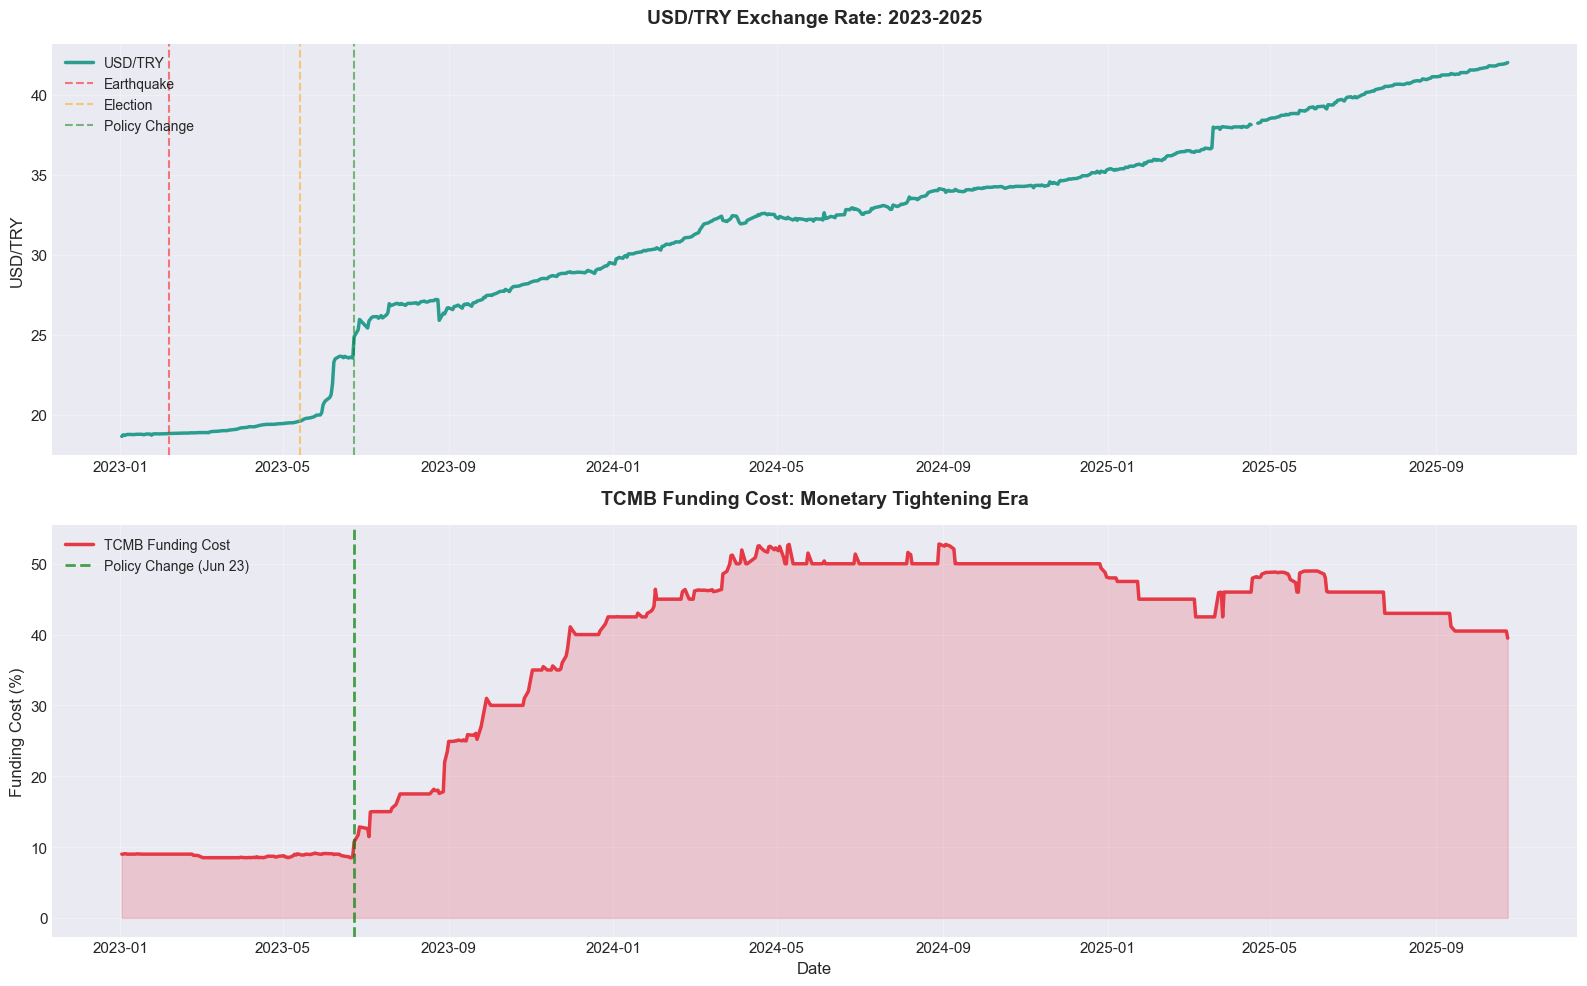


📊 USD/TRY Summary:
   Starting rate:  18.6447
   Ending rate:    42.0311
   Depreciation:   +125.43%
   Peak:           42.0311 on 2025-10-24

📊 TCMB Funding Cost Summary:
   Pre-Jun 23 avg:  8.79%
   Post-Jun 23 avg: 42.64%
   Increase:        +33.85 percentage points
   Peak rate:       52.79% on 2024-08-29


In [12]:
# USD/TRY and Funding Cost analysis
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: USD/TRY
ax1 = axes[0]
ax1.plot(df['date'], df['USD_TRY'], linewidth=2.5, color='#2A9D8F', label='USD/TRY')
ax1.axvline(pd.Timestamp('2023-02-06'), color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Earthquake')
ax1.axvline(pd.Timestamp('2023-05-14'), color='orange', linestyle='--', linewidth=1.5, alpha=0.5, label='Election')
ax1.axvline(pd.Timestamp('2023-06-23'), color='green', linestyle='--', linewidth=1.5, alpha=0.5, label='Policy Change')
ax1.set_title('USD/TRY Exchange Rate: 2023-2025', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('USD/TRY', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: TCMB Funding Cost
ax2 = axes[1]
if 'Funding_Cost' in df.columns:
    ax2.plot(df['date'], df['Funding_Cost'], linewidth=2.5, color='#E63946', label='TCMB Funding Cost')
    ax2.axvline(pd.Timestamp('2023-06-23'), color='green', linestyle='--', linewidth=2, alpha=0.7,
               label='Policy Change (Jun 23)')
    ax2.fill_between(df['date'], 0, df['Funding_Cost'], alpha=0.2, color='#E63946')
    ax2.set_title('TCMB Funding Cost: Monetary Tightening Era', fontsize=14, fontweight='bold', pad=15)
    ax2.set_ylabel('Funding Cost (%)', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.legend(loc='upper left', fontsize=10)
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Funding Cost data not available', 
            ha='center', va='center', transform=ax2.transAxes, fontsize=12)

plt.tight_layout()
plt.savefig('eda_traditional_indicators.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 USD/TRY Summary:")
print(f"   Starting rate:  {df['USD_TRY'].iloc[0]:.4f}")
print(f"   Ending rate:    {df['USD_TRY'].iloc[-1]:.4f}")
print(f"   Depreciation:   {((df['USD_TRY'].iloc[-1] / df['USD_TRY'].iloc[0]) - 1) * 100:+.2f}%")
print(f"   Peak:           {df['USD_TRY'].max():.4f} on {df.loc[df['USD_TRY'].idxmax(), 'date'].date()}")

if 'Funding_Cost' in df.columns:
    print("\n📊 TCMB Funding Cost Summary:")
    pre_june = df[df['date'] < '2023-06-23']['Funding_Cost'].mean()
    post_june = df[df['date'] >= '2023-06-23']['Funding_Cost'].mean()
    print(f"   Pre-Jun 23 avg:  {pre_june:.2f}%")
    print(f"   Post-Jun 23 avg: {post_june:.2f}%")
    print(f"   Increase:        +{post_june - pre_june:.2f} percentage points")
    print(f"   Peak rate:       {df['Funding_Cost'].max():.2f}% on {df.loc[df['Funding_Cost'].idxmax(), 'date'].date()}")

---

## 4. Correlation Analysis

Examining relationships between variables.

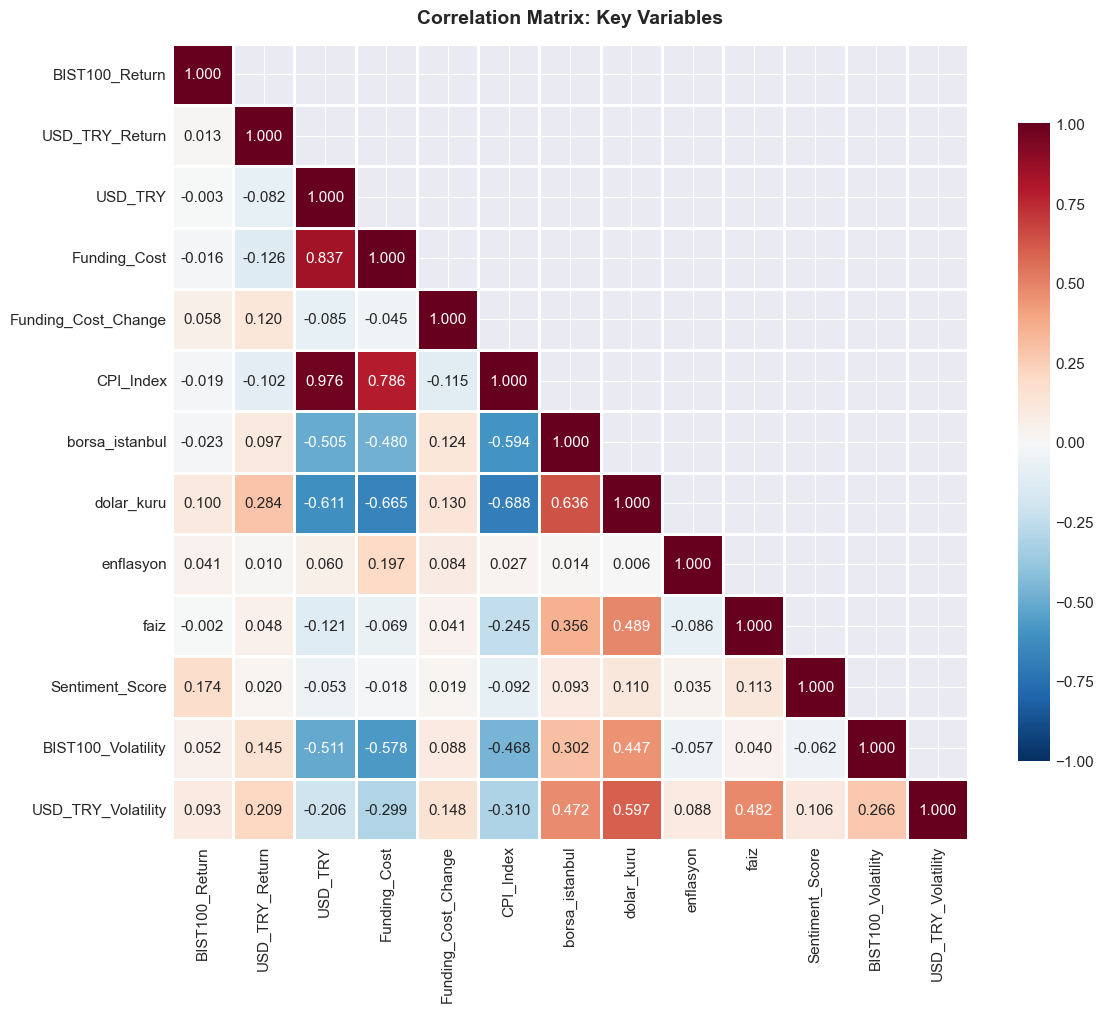


📊 Strongest Correlations with BIST100_Return:
   Sentiment_Score          :  0.1735
   dolar_kuru               :  0.1004
   USD_TRY_Volatility       :  0.0927
   Funding_Cost_Change      :  0.0579
   BIST100_Volatility       :  0.0525
   enflasyon                :  0.0411
   borsa_istanbul           : -0.0226
   CPI_Index                : -0.0192
   Funding_Cost             : -0.0158
   USD_TRY_Return           :  0.0135
   USD_TRY                  : -0.0033
   faiz                     : -0.0016


In [25]:
# Select key variables for correlation analysis
key_vars = [
    'BIST100_Return',
    'USD_TRY_Return',
    'USD_TRY',
    'Funding_Cost',
    'Funding_Cost_Change',
    'CPI_Index', 
    'borsa_istanbul',
    'dolar_kuru',
    'enflasyon',
    'faiz',
    'Sentiment_Score',
    'BIST100_Volatility',
    'USD_TRY_Volatility'          # Volatility
]

# Filter available variables
available_vars = [v for v in key_vars if v in df.columns]

# Create correlation matrix
corr_matrix = df[available_vars].corr()

# Visualization
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # k=1 ekle!
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', 
            cmap='RdBu_r', center=0, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix: Key Variables', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Strongest Correlations with BIST100_Return:")
bist_corr = corr_matrix['BIST100_Return'].drop('BIST100_Return').abs().sort_values(ascending=False)
for var, corr in bist_corr.items():
    actual_corr = corr_matrix.loc['BIST100_Return', var]
    print(f"   {var:25s}: {actual_corr:>7.4f}")

---

## 5. Event Analysis

Deep dive into major events and their market impact.

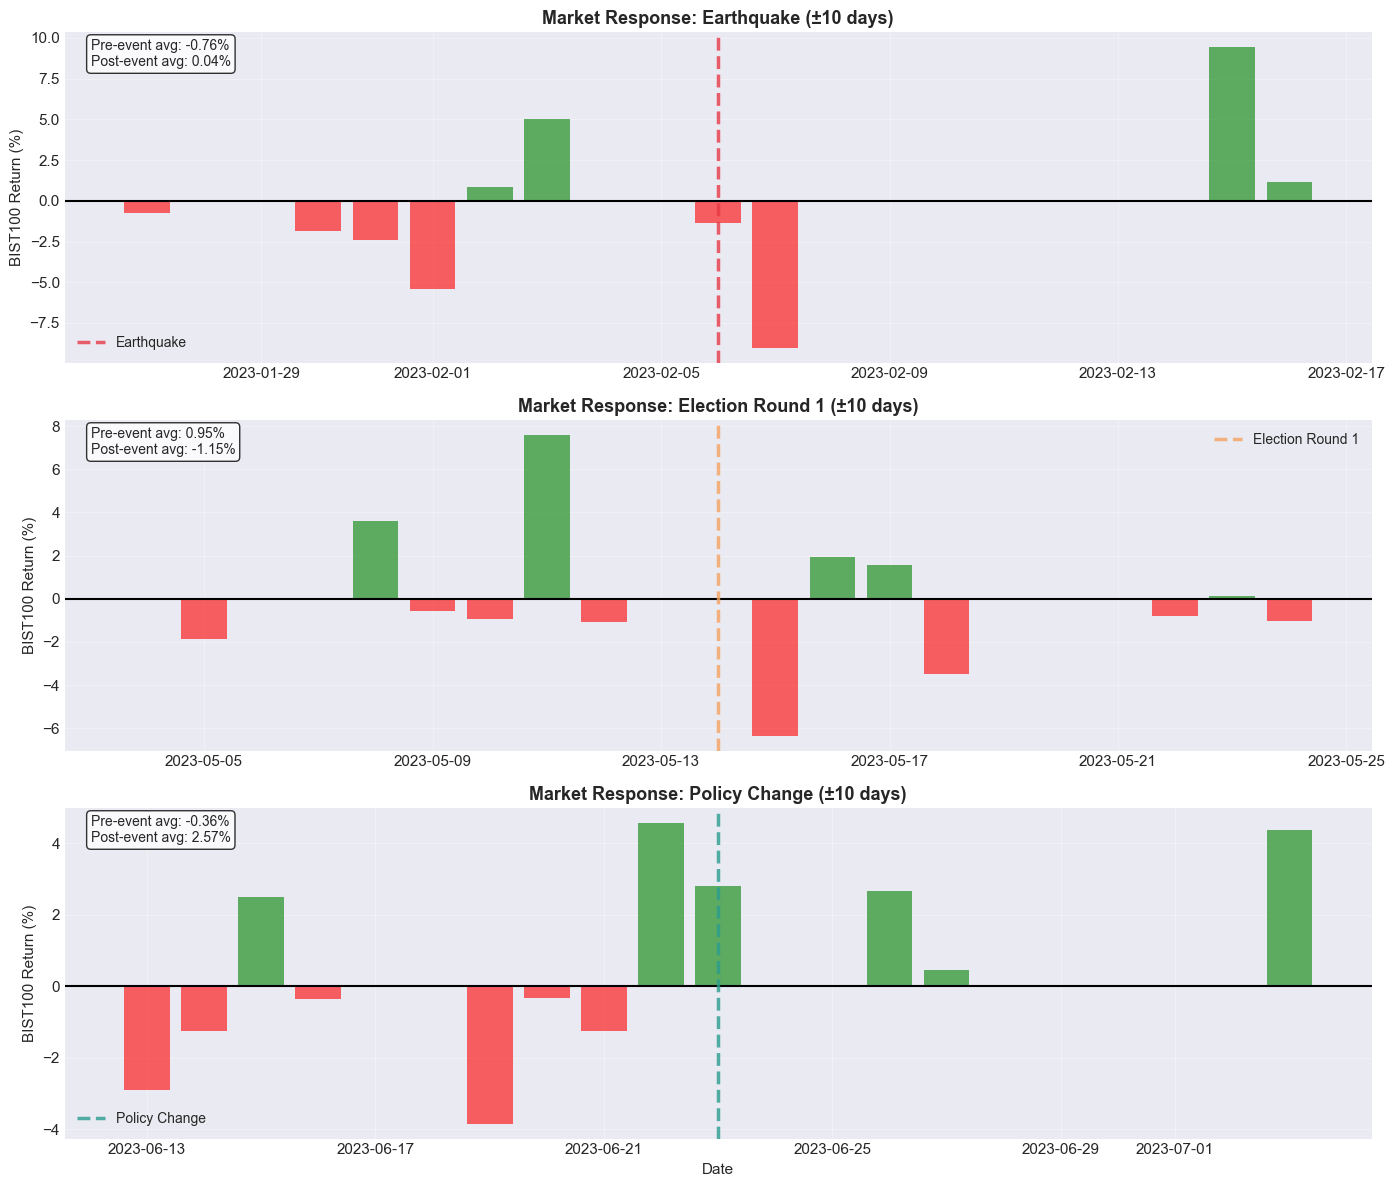


📊 Event Impact Summary:

   Earthquake:
     Pre-event avg:    -0.76%
     Post-event avg:    0.04%
     Change:           +0.80%

   Election Round 1:
     Pre-event avg:     0.95%
     Post-event avg:   -1.15%
     Change:           -2.10%

   Policy Change:
     Pre-event avg:    -0.36%
     Post-event avg:    2.57%
     Change:           +2.93%


In [14]:
# Event impact analysis
events = [
    {'name': 'Earthquake', 'date': '2023-02-06', 'window': 10, 'color': '#E63946'},
    {'name': 'Election Round 1', 'date': '2023-05-14', 'window': 10, 'color': '#F4A261'},
    {'name': 'Policy Change', 'date': '2023-06-23', 'window': 10, 'color': '#2A9D8F'}
]

fig, axes = plt.subplots(len(events), 1, figsize=(14, 4*len(events)))

if len(events) == 1:
    axes = [axes]

for i, event in enumerate(events):
    ax = axes[i]
    event_date = pd.Timestamp(event['date'])
    window = event['window']
    
    # Get data around event
    event_data = df[
        (df['date'] >= event_date - pd.Timedelta(days=window)) &
        (df['date'] <= event_date + pd.Timedelta(days=window))
    ]
    
    # Plot returns
    colors = ['red' if x < 0 else 'green' for x in event_data['BIST100_Return']]
    ax.bar(event_data['date'], event_data['BIST100_Return'], 
          color=colors, alpha=0.6, width=0.8)
    ax.axhline(0, color='black', linewidth=1.5)
    ax.axvline(event_date, color=event['color'], linestyle='--', 
              linewidth=2.5, label=f"{event['name']}", alpha=0.8)
    
    ax.set_title(f"Market Response: {event['name']} (±{window} days)", 
                fontsize=13, fontweight='bold')
    ax.set_ylabel('BIST100 Return (%)', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    pre_event = event_data[event_data['date'] < event_date]['BIST100_Return'].mean()
    post_event = event_data[event_data['date'] >= event_date]['BIST100_Return'].mean()
    
    stats_text = f'Pre-event avg: {pre_event:.2f}%\nPost-event avg: {post_event:.2f}%'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
           fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[-1].set_xlabel('Date', fontsize=11)

plt.tight_layout()
plt.savefig('eda_event_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Event Impact Summary:")
for event in events:
    event_date = pd.Timestamp(event['date'])
    window = event['window']
    event_data = df[
        (df['date'] >= event_date - pd.Timedelta(days=window)) &
        (df['date'] <= event_date + pd.Timedelta(days=window))
    ]
    pre = event_data[event_data['date'] < event_date]['BIST100_Return'].mean()
    post = event_data[event_data['date'] >= event_date]['BIST100_Return'].mean()
    
    print(f"\n   {event['name']}:")
    print(f"     Pre-event avg:  {pre:>7.2f}%")
    print(f"     Post-event avg: {post:>7.2f}%")
    print(f"     Change:         {post - pre:>+7.2f}%")

---

## 6. Volatility Analysis

Examining market volatility patterns and clustering.

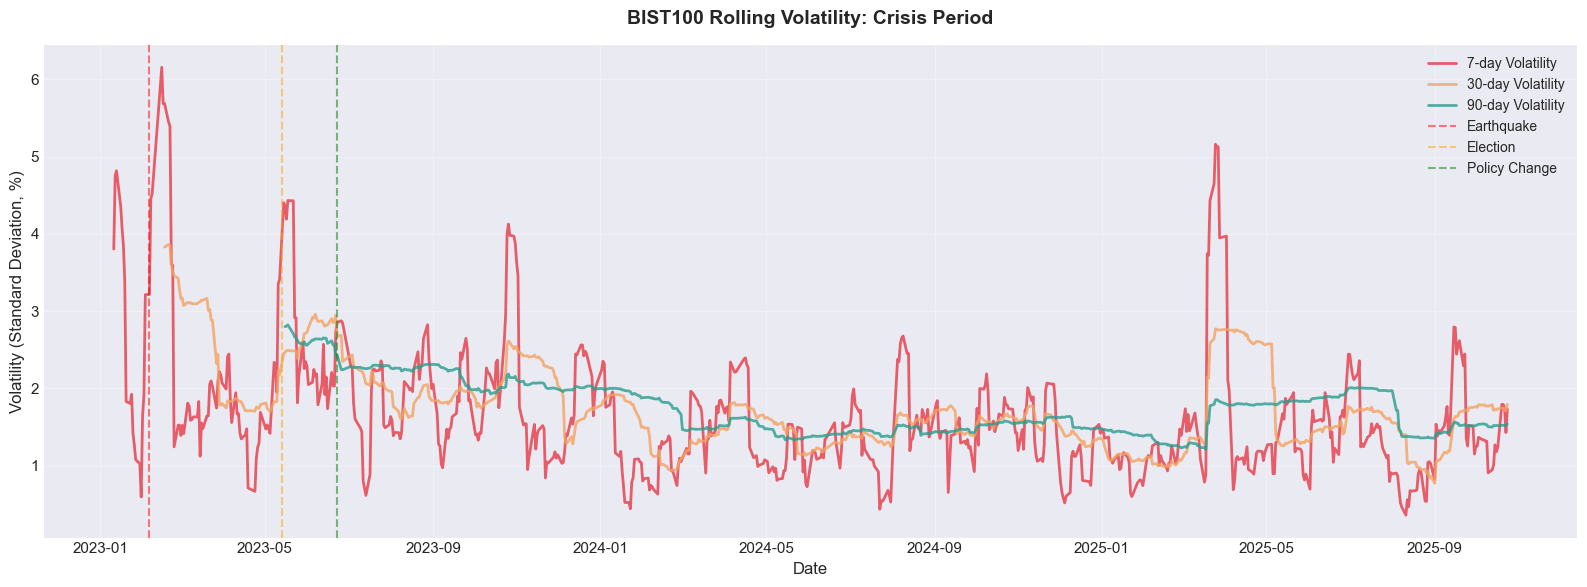


📊 Volatility Summary:

   7-day Rolling Volatility:
     Mean:    1.6428%
     Max:     6.1560% on 2023-02-15
     Current: 1.7359%

   30-day Rolling Volatility:
     Mean:    1.7410%
     Max:     3.8622% on 2023-02-20
     Current: 1.7933%

   90-day Rolling Volatility:
     Mean:    1.7462%
     Max:     2.8222% on 2023-05-18
     Current: 1.5406%


In [15]:
# Rolling volatility analysis
windows = [7, 30, 90]

fig, ax = plt.subplots(figsize=(16, 6))

colors_vol = ['#E63946', '#F4A261', '#2A9D8F']

for window, color in zip(windows, colors_vol):
    rolling_vol = df['BIST100_Return'].rolling(window=window).std()
    ax.plot(df['date'], rolling_vol, linewidth=2, color=color, 
           label=f'{window}-day Volatility', alpha=0.8)

# Mark key events
ax.axvline(pd.Timestamp('2023-02-06'), color='red', linestyle='--', 
          linewidth=1.5, alpha=0.5, label='Earthquake')
ax.axvline(pd.Timestamp('2023-05-14'), color='orange', linestyle='--', 
          linewidth=1.5, alpha=0.5, label='Election')
ax.axvline(pd.Timestamp('2023-06-23'), color='green', linestyle='--', 
          linewidth=1.5, alpha=0.5, label='Policy Change')

ax.set_title('BIST100 Rolling Volatility: Crisis Period', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Volatility (Standard Deviation, %)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_volatility_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Volatility Summary:")
for window in windows:
    vol = df['BIST100_Return'].rolling(window=window).std()
    print(f"\n   {window}-day Rolling Volatility:")
    print(f"     Mean:    {vol.mean():.4f}%")
    print(f"     Max:     {vol.max():.4f}% on {df.loc[vol.idxmax(), 'date'].date()}")
    print(f"     Current: {vol.iloc[-1]:.4f}%")

---

## 7. Summary Statistics

Comprehensive statistical overview of all key variables.

In [16]:
# Summary statistics for key variables
summary_vars = [
    'BIST100_Return',
    'USD_TRY_Return',
    'Funding_Cost',
    'dolar_kuru',
    'enflasyon',
    'Sentiment_Score'
]

available_summary = [v for v in summary_vars if v in df.columns]

summary_stats = df[available_summary].describe().T
summary_stats['skewness'] = df[available_summary].skew()
summary_stats['kurtosis'] = df[available_summary].kurtosis()

print("\n📊 COMPREHENSIVE SUMMARY STATISTICS")
print("="*80)
print(summary_stats.to_string())

# Export to file
summary_stats.to_csv('eda_summary_statistics.csv')
print("\n✅ Summary statistics saved to 'eda_summary_statistics.csv'")


📊 COMPREHENSIVE SUMMARY STATISTICS
                 count       mean        std       min        25%        50%        75%        max  skewness   kurtosis
BIST100_Return   700.0   0.094140   1.875321 -9.123328  -0.930573   0.037549   1.202963   9.423413 -0.261510   3.661648
USD_TRY_Return   697.0   0.116274   0.502780 -4.852286  -0.012729   0.065976   0.186580   6.020530  3.852619  65.058096
Funding_Cost     701.0  36.991084  15.490670  8.500000  25.800000  45.000000  50.000000  52.790000 -0.948289  -0.738083
dolar_kuru       701.0  16.967190  14.394612  5.142857   7.000000  11.000000  20.571429  93.571429  2.215400   5.749569
enflasyon        701.0   4.851641   2.527089  1.142857   3.000000   4.000000   6.285714  15.857143  1.209396   1.220443
Sentiment_Score  700.0  -0.319098   0.264972 -0.986808  -0.489125  -0.330120  -0.152921   0.887214  0.377347   1.137436

✅ Summary statistics saved to 'eda_summary_statistics.csv'


---

## 8. Key Insights for Hypothesis Testing

Based on this exploratory analysis, we identified several patterns that informed our hypothesis tests:

### 📌 Main Findings:

1. **Earthquake Impact (Feb 6, 2023)**
   - Immediate severe market reaction (-9.01% crash)
   - Triggered 5-day market closure
   - Clear abnormal returns visible in event window
   - **→ Led to H1: Earthquake impact hypothesis**

2. **Election Period (May 2023)**
   - Increased volatility around election dates
   - But overshadowed by earthquake aftermath
   - **→ Led to H2: Election volatility hypothesis**

3. **Policy Regime Change (Jun 23, 2023)**
   - Sharp increase in funding cost (8.5% → 50%)
   - Potential structural break in market dynamics
   - **→ Led to H3: Structural break hypothesis**

4. **Digital Panic Indicators**
   - Google Trends spikes coincide with market volatility
   - "Dolar kuru" searches strongest predictor
   - **→ Led to H4: Google Trends-volatility correlation**

5. **Social Sentiment**
   - Ekşi Sözlük sentiment predominantly negative (90.5%)
   - Moderate same-day correlation with returns (r=0.17)
   - Weak leading correlation (r=0.003)
   - **→ Led to H5: Sentiment prediction hypothesis**

6. **Traditional vs Digital Indicators**
   - Traditional indicators show weak individual correlations
   - Digital indicators appear more strongly linked to volatility
   - **→ Led to H6: Hybrid model comparison**

---

### 🎯 Next Steps:

These exploratory findings guided the formal hypothesis tests documented in `hypothesis_tests`:

- **H1:** Earthquake caused significant negative returns ✅
- **H2:** Elections increased market volatility ⚠️
- **H3:** Policy change created structural break ❌
- **H4:** Google Trends correlate with volatility ✅
- **H5:** Sentiment predicts future returns ❌
- **H6:** Hybrid model outperforms traditional ✅

---

**End of EDA**